In [1]:
from music21 import stream, note, meter, key
from collections import defaultdict
import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random


In [2]:
with open('rhythm_dict/rhythm_dict_with_cleanup_20dec25.pkl', 'rb') as f:
    rhythm_dict = pickle.load(f)

with open('markov_dict/pitch_markov_restrictedG3E6.pkl', 'rb') as f:
    pitch_markov_prob = pickle.load(f)

In [ ]:
# ===============================
# GRADE SETTINGS
# ===============================

GRADE_SETTINGS = {

    "initial": {

        "structures": [
            {"bars": 4, "time_signature": "4/4"},
            {"bars": 6, "time_signature": "2/4"}
        ],

        "keys": ["C_major", "D_minor"],

        "hands": "separate",
        "position": "5_finger",

        "max_interval": 4,
        "allowed_durations": {1.0, 0.5, 2.0}
    },

}

def sample_grade_parameters(grade):

    settings = GRADE_SETTINGS[grade]

    structure = random.choice(settings["structures"])

    params = {
        "bars": structure["bars"],
        "time_signature": structure["time_signature"],
        "key": random.choice(settings["keys"]),
        "hands": settings["hands"],
        "position": settings["position"],
        "max_interval": settings["max_interval"],
        "durations": settings["allowed_durations"]
    }

    return params

In [ ]:
# ===============================
# KEY SETTINGS
# ===============================

SCALE_PATTERNS = { #semitone distances from the tonic
    "major": [0, 2, 4, 5, 7, 9, 11],
    "natural_minor": [0, 2, 3, 5, 7, 8, 10],
    "harmonic_minor": [0, 2, 3, 5, 7, 8, 11]
} 


ALLOWED_DURATIONS = {1.0, 0.5, 2.0}



def build_scale(tonic_midi, scale_type): #generates scale notes
    intervals = SCALE_PATTERNS[scale_type]
    return {tonic_midi + i for i in intervals}

def build_triad(tonic_midi, scale_type): #builds tonic triad
    scale = sorted(build_scale(tonic_midi, scale_type))
    return [scale[0], scale[2], scale[4]]


def build_cadences(tonic_midi, scale_type, bars):

    scale = sorted(build_scale(tonic_midi, scale_type))

    dominant = scale[4]
    tonic = scale[0]

    if bars == 4:
        return {2: dominant, 4: tonic}

    if bars == 6:
        return {3: dominant, 6: tonic}


def build_key_settings(tonic_midi, scale_type, music21_name): #builds a full key configuration

    notes = build_scale(tonic_midi, scale_type)
    triad = build_triad(tonic_midi, scale_type)
    cadences = build_cadences(tonic_midi, scale_type)

    return {
        "notes": notes,
        "cadences": cadences,
        "start": triad,
        "music21_key": music21_name
    }


KEY_SETTINGS = {
    "C_major": build_key_settings(
        60,
        "major",
        ("C", "major")
    ),
    "D_minor": build_key_settings(
        62,
        "natural_minor",
        ("D", "minor")
    )

}


In [ ]:
# ===============================
# UTILITY FUNCTIONS
# ===============================

def normalize(weight_dict):
    total = sum(weight_dict.values())
    if total == 0:
        return {}
    return {k: v / total for k, v in weight_dict.items()}

def weighted_sample(prob_dict):
    if not prob_dict:
        return None
    items = list(prob_dict.keys())
    weights = list(prob_dict.values())
    return random.choices(items, weights=weights, k=1)[0]

# ===============================
# RHYTHM FILTER
# ===============================

def is_valid_rhythm(pattern, beats_per_bar):
    if abs(sum(pattern) - beats_per_bar) > 1e-6:
        return False
    return all(d in ALLOWED_DURATIONS for d in pattern)

def get_valid_rhythms(rhythm_dict, time_signature):

    beats = int(time_signature.split("/")[0])

    patterns = rhythm_dict.get(time_signature, {})

    return {
        p: c
        for p, c in patterns.items()
        if is_valid_rhythm(p, beats)
    }

def sample_rhythm(initial_rhythms):
    probs = normalize(initial_rhythms)
    return weighted_sample(probs)

# ===============================
# MARKOV CONSTRAINTS
# ===============================

def constrained_transitions(prev_note, pitch_markov_prob, allowed_notes):
    raw = pitch_markov_prob.get(prev_note, {})
    filtered = {}

    for nxt, prob in raw.items():
        if nxt in allowed_notes and abs(nxt - prev_note) <= 4:
            filtered[nxt] = prob

    # fallback if empty
    if not filtered:
        for candidate in allowed_notes:
            if abs(candidate - prev_note) <= 2:
                filtered[candidate] = 1.0

    return filtered

def pedagogical_bias(prev_note, candidates, bar_number):
    for nxt in list(candidates.keys()):
        # Stepwise boost
        if abs(nxt - prev_note) <= 2:
            candidates[nxt] *= 1.5 #to encourage steps up to 2 semitones

        # Phrase direction
        if bar_number <= 2 and nxt > prev_note:
            candidates[nxt] *= 1.2
        if bar_number > 2 and nxt < prev_note:
            candidates[nxt] *= 1.2

    return candidates

# ===============================
# BAR GENERATION
# ===============================

def generate_bar(prev_note, bar_number, rhythm, pitch_markov_prob, allowed_notes, cadences):

    bar_notes = []

    for dur in rhythm:

        candidates = constrained_transitions(prev_note, pitch_markov_prob, allowed_notes)
        candidates = pedagogical_bias(prev_note, candidates, bar_number)
        candidates = normalize(candidates)

        next_note = weighted_sample(candidates)

        if next_note is None:
            next_note = random.choice(list(ALLOWED_NOTES))

        bar_notes.append((next_note, dur))
        prev_note = next_note

    # enforce cadence
    if bar_number in cadences:
        target = cadences[bar_number]
        bar_notes[-1] = (target, bar_notes[-1][1])
        prev_note = target

    return bar_notes, prev_note

# ===============================
# FULL EXERCISE GENERATOR
# ===============================

def generate_exercise(pitch_markov_prob, rhythm_dict, key_name="C_major"):

    settings = KEY_SETTINGS[key_name]
    allowed_notes = settings["notes"]
    cadences = settings["cadences"]
    start_notes = settings["start"]

    #initial_rhythms = get_initial_rhythms(rhythm_dict)

    params = sample_grade_parameters(grade)

    valid_rhythms = get_valid_rhythms(
        rhythm_dict,
        params["time_signature"]
    )

    if not valid_rhythms:
        raise ValueError("No valid rhythms found.")

    exercise = []
    prev_note = random.choice(start_notes)  # start stable

    for bar_number in range(1, 5):

        rhythm = sample_rhythm(valid_rhythms)
        bar, prev_note = generate_bar(
            prev_note,
            bar_number,
            rhythm,
            pitch_markov_prob,
            allowed_notes,
            cadences
        )

        exercise.append(bar)

    return exercise

# ===============================
# RENDER WITH MUSIC21
# ===============================

def render_exercise(exercise, key_name="C_major"):
    #print(exercise)

    settings = KEY_SETTINGS[key_name]
    tonic, mode = settings["music21_key"]

    score = stream.Score()
    part = stream.Part()

    part.append(key.Key(tonic, mode))
    part.append(meter.TimeSignature("4/4"))

    for bar_data in exercise:
        m = stream.Measure()
        for midi_pitch, dur in bar_data:
            n = note.Note()
            n.pitch.midi = midi_pitch
            n.quarterLength = dur
            m.append(n)
        part.append(m)

    score.append(part)
    score.show()


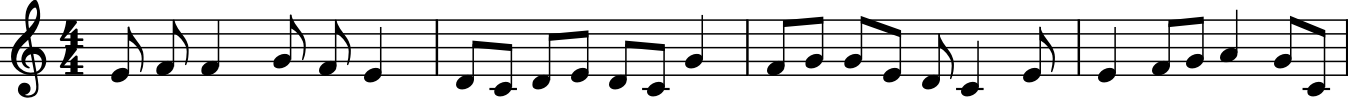

In [7]:
exercise = generate_exercise(pitch_markov_prob, rhythm_dict, "C_major")
render_exercise(exercise, "C_major")